# LeNet-5 Model Implementation

In this notebook, you will:
- Build LeNet-5 for **Handwriting Recognition (Gray Scale Image)** using the TF Keras Functional API

# Load Library

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.keras.datasets import mnist # We will remove it later

# Handwriting Recognition (Gray Scale Image)

We'll use Keras' flexible [Functional API](https://www.tensorflow.org/guide/keras/functional) to build a **LeNet-5 Model** that can **recognize** between **0-9 handwriting**.

<img src="images/LeNet-5_Architecture.png">

## 1. Load Data and Split into Train/Test Sets

### 1.1 - Load Data

In [2]:
(train_set_x_orig, train_set_y_orig), (test_set_x_orig, test_set_y_orig) = mnist.load_data()
list_classes = np.unique(train_set_y_orig)

In [3]:
# ======= TRAINING SET =======
print("train_set_x_orig shape:", train_set_x_orig.shape)
print("train_set_y_orig shape:", train_set_y_orig.shape)

train_set_x_orig shape: (60000, 28, 28)
train_set_y_orig shape: (60000,)


In [4]:
# ======= TEST SET =======
print("test_set_x_orig shape:", test_set_x_orig.shape)
print("test_set_y_orig shape:", test_set_y_orig.shape)

test_set_x_orig shape: (10000, 28, 28)
test_set_y_orig shape: (10000,)


In [5]:
# ======= CLASSES =======
print("Classes shape:", list_classes.shape)

Classes shape: (10,)


**_Note_**: We can see that:
- **X - feature**: is in **incorrect** format of `(batch_size, height, weight, channels)`. It is lack of `channels`
- **Y - label** is in **incorrect** format. We need `(1, #label)` - a 2D format, not in 1D vector

⇒ We need to convert both X and Y to correct format

y = 3


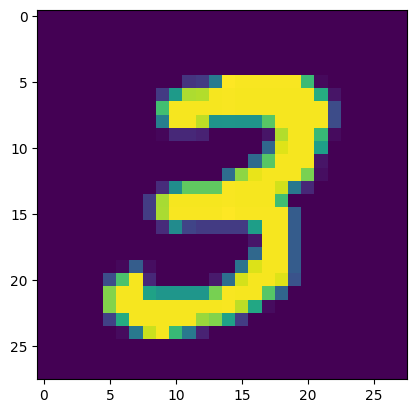

In [6]:
# Example of an image from the dataset
index = 7
plt.imshow(train_set_x_orig[index])
print ("y = " + str(np.squeeze(train_set_y_orig[index])))

### 1.2 - Convert X and Y into Correct Format

We need to do that because it helps:
- **Easier for compute Loss**
- **Match with Output model**

**_Note:_** We do **NOT need** to **convert classes** because it does **NOT participate** in the **calculation** nor **input** for the **model**.

#### 1.2.1 - Convert X

We convert from: `(batch_size, height, weight)` => `(batch_size, height, weight, channels)`

In [7]:
# ======= Convert X =======
img_height, img_width = train_set_x_orig.shape[1], train_set_x_orig.shape[2]

train_set_x_orig = train_set_x_orig.reshape(-1, img_height, img_width, 1)
test_set_x_orig = test_set_x_orig.reshape(-1, img_height, img_width, 1)
print("train_set_x_orig shape:", train_set_x_orig.shape)
print("test_set_x_orig shape:", test_set_x_orig.shape)

train_set_x_orig shape: (60000, 28, 28, 1)
test_set_x_orig shape: (10000, 28, 28, 1)


#### 1.2.2 - Convert Y

We convert from: 1D `(#label,)` => 2D `(1, #label)`

In [8]:
# ======= Convert Y =======
train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
print("train_set_y_orig shape:", train_set_y_orig.shape)
print("test_set_y_orig shape:", test_set_y_orig.shape)

train_set_y_orig shape: (1, 60000)
test_set_y_orig shape: (1, 10000)


### 1.3 - Convert Classes to One-Hot Representation

We need to know what the representation of classes is to know how we can convert it to One-hot representation.

In [9]:
print("Train: y = " + str(np.squeeze(train_set_y_orig)) + ", Size: " + str(train_set_y_orig.shape))

Train: y = [5 0 4 ... 5 6 8], Size: (1, 60000)


In [10]:
def convert_to_one_hot(Y, C):
    Y = np.eye(C)[Y.reshape(-1)].T
    return Y

### 1.4 - Split Data

Images are **28x28** pixels in Gray format (1 channels):
- **X_train/X_test shape**: `(batch_size, height, width, channels)`
- **Y_train/Y_test shape**: `(batch_size, #classes_one_hot_represent)`
- **Classes shape**: `(#classes,)`

In [11]:
# Normalize image vectors
X_train = train_set_x_orig/255.
X_test = test_set_x_orig/255.

# Reshape + Convert Y to One-hot
Y_train = convert_to_one_hot(train_set_y_orig, list_classes.shape[0]).T
Y_test = convert_to_one_hot(test_set_y_orig, list_classes.shape[0]).T

# Classes
classes = list_classes

print ("Number of training examples = " + str(X_train.shape[0]))
print ("Number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))
print ("Classes shape: " + str(classes.shape))

Number of training examples = 60000
Number of test examples = 10000
X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)
X_test shape: (10000, 28, 28, 1)
Y_test shape: (10000, 10)
Classes shape: (10,)


## 2 - Model Processing

### 2.1 - Create LeNet-5 Model Pipeline

<img src="images/LeNet-5_Pipeline.png">

Use the functions above!

Also, plug in the following parameters for all the steps:

 - [Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D): Use 6 5 by 5 filters, stride 1, padding is "VALID"
 - [Sigmoid](https://www.tensorflow.org/api_docs/python/tf/keras/activations/sigmoid)
 - [AvgPool2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/AvgPool2D): Use an 2 by 2 filter size and an 2 by 2 stride, padding is "VALID"
 - **Sigmoid**
 - **Conv2D**: Use 16 5 by 5 filters, stride 1, padding is "VALID"
 - **Sigmoid**
 - **AvgPool2D**: Use an 2 by 2 filter size and an 2 by 2 stride, padding is "VALID"
 - **Sigmoid**
 - [Flatten](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten) the previous output.
 - Fully-connected ([Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)) layer: Apply a fully connected layer with 120 neurons.
 - **Sigmoid**
 - **Dense**: Apply a fully connected layer with 84 neurons.
 - **Sigmoid**
 - **Dense**: Apply a fully connected layer with 10 neurons.
 - [Softmax](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Softmax): Output probabilities for 10 classes.